# UFC Fight Analytics & Prediction (1993–2026)

This project analyzes UFC fight data and fighter profiles to uncover performance patterns and predict fight outcomes.

Objectives:
- Analyze fight statistics and trends
- Study striking, grappling, and control dominance
- Explore fighter physical advantages
- Identify winning patterns
- Build a machine learning model to predict fight outcomes

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

plt.style.use("ggplot")

In [2]:
fights = pd.read_csv("archive(1)/ufc_gold_dataset_final.csv")
fighters = pd.read_csv("archive(1)/ufc_fighters_final.csv")

fights["Event_Date"] = pd.to_datetime(fights["Event_Date"])
fighters["DOB"] = pd.to_datetime(fighters["DOB"])

fights.head()

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,...,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,...,0,0,0,0,0,1,0,0,0,1994-03-11
1,http://ufcstats.com/fight-details/4b9ae533ccb3...,Patrick Smith,Ray Wizard,Patrick Smith,Open Weight Bout,Submission,1,0:58,58,No Time Limit,...,0,0,1,0,1,1,0,0,0,1994-03-11
2,http://ufcstats.com/fight-details/00835554f95f...,Royce Gracie,Patrick Smith,Royce Gracie,UFC 2 Tournament Title Bout,KO/TKO,1,1:17,77,No Time Limit,...,1,1,0,0,0,1,1,3,0,1994-03-11
3,http://ufcstats.com/fight-details/aa161c715974...,Royce Gracie,Remco Pardoel,Royce Gracie,Open Weight Bout,Submission,1,1:31,91,No Time Limit,...,0,0,0,0,0,0,0,0,0,1994-03-11
4,http://ufcstats.com/fight-details/8fbdde20b712...,Patrick Smith,Johnny Rhodes,Patrick Smith,Open Weight Bout,Submission,1,1:07,67,No Time Limit,...,0,2,2,3,4,2,0,0,0,1994-03-11


In [3]:
print("Fights:", fights.shape)
print("Fighters:", fighters.shape)

fights.info()
fighters.info()

Fights: (8551, 37)
Fighters: (4455, 18)
<class 'pandas.DataFrame'>
RangeIndex: 8551 entries, 0 to 8550
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Fight_URL             8551 non-null   str           
 1   Fighter_1             8551 non-null   str           
 2   Fighter_2             8551 non-null   str           
 3   Winner                8551 non-null   str           
 4   Weight_Class          8551 non-null   str           
 5   Method                8551 non-null   str           
 6   End_Round             8551 non-null   int64         
 7   End_Time              8551 non-null   str           
 8   Total_Fight_Time_Sec  8551 non-null   int64         
 9   Time_Format           8551 non-null   str           
 10  F1_KD                 8551 non-null   int64         
 11  F2_KD                 8551 non-null   int64         
 12  F1_Sig_Landed         8551 non-null   int64    

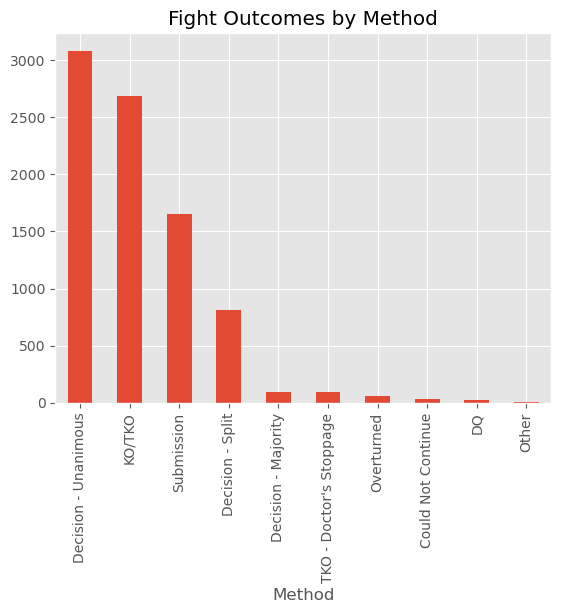

In [4]:
fights["Method"].value_counts().plot(kind="bar")

plt.title("Fight Outcomes by Method")

plt.show()

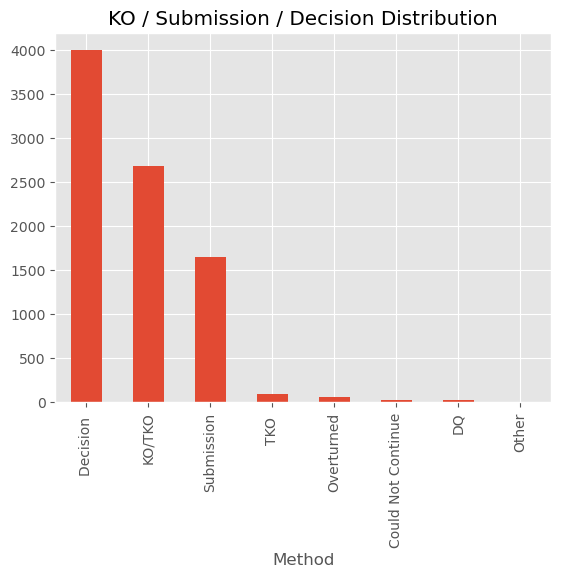

In [5]:
methods = fights["Method"].str.split("-").str[0]

methods.value_counts().plot(kind="bar")

plt.title("KO / Submission / Decision Distribution")

plt.show()

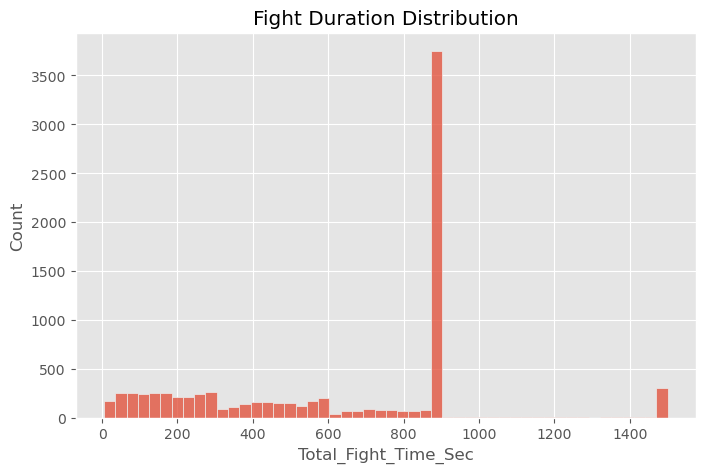

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(fights["Total_Fight_Time_Sec"], bins=50)

plt.title("Fight Duration Distribution")

plt.show()

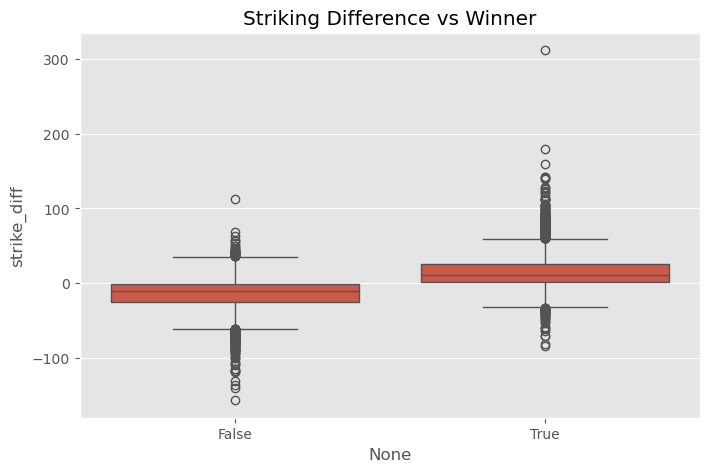

In [7]:
fights["strike_diff"] = fights["F1_Sig_Landed"] - fights["F2_Sig_Landed"]

plt.figure(figsize=(8,5))

sns.boxplot(
    x=fights["Winner"] == fights["Fighter_1"],
    y=fights["strike_diff"]
)

plt.title("Striking Difference vs Winner")

plt.show()

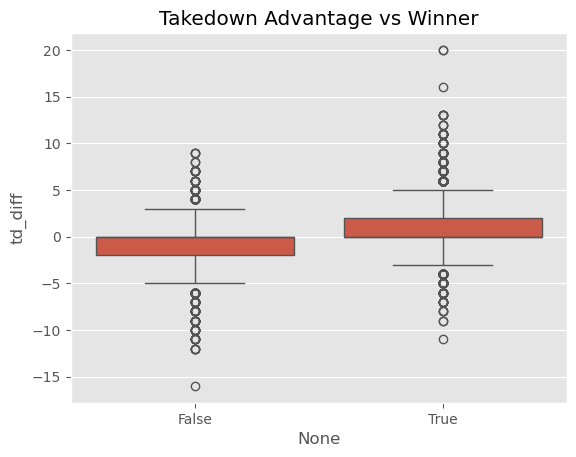

In [8]:
fights["td_diff"] = fights["F1_TD_Landed"] - fights["F2_TD_Landed"]

sns.boxplot(
    x=fights["Winner"] == fights["Fighter_1"],
    y=fights["td_diff"]
)

plt.title("Takedown Advantage vs Winner")

plt.show()

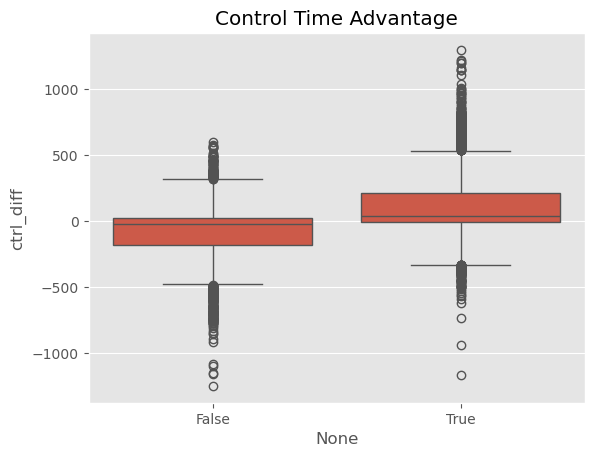

In [9]:
fights["ctrl_diff"] = fights["F1_Ctrl_Sec"] - fights["F2_Ctrl_Sec"]

sns.boxplot(
    x=fights["Winner"] == fights["Fighter_1"],
    y=fights["ctrl_diff"]
)

plt.title("Control Time Advantage")

plt.show()

In [16]:

fighters.columns = fighters.columns.str.strip()
fights.columns = fights.columns.str.strip()


fighters_small = fighters[[
    "Fighter_Name",
    "Height",
    "Reach",
    "Weight",
    "SLpM",
    "Str_Acc",
    "TD_Avg"
]].copy()

fights = fights.merge(
    fighters_small,
    left_on="Fighter_1",
    right_on="Fighter_Name",
    how="left"
)


fights.rename(columns={
    "Height": "F1_Height",
    "Reach": "F1_Reach",
    "Weight": "F1_Weight",
    "SLpM": "F1_SLpM"
}, inplace=True)

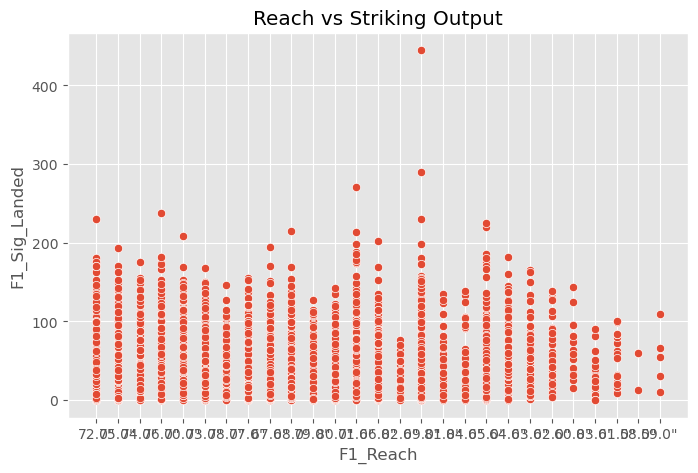

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=fights["F1_Reach"],
    y=fights["F1_Sig_Landed"]
)

plt.title("Reach vs Striking Output")

plt.show()

In [18]:

fights["F1_dominance"] = (
    fights["F1_Sig_Landed"] * 0.4 +
    fights["F1_TD_Landed"] * 0.3 +
    fights["F1_Sub_Att"] * 0.2 +
    fights["F1_Ctrl_Sec"] * 0.001
)

fights["F2_dominance"] = (
    fights["F2_Sig_Landed"] * 0.4 +
    fights["F2_TD_Landed"] * 0.3 +
    fights["F2_Sub_Att"] * 0.2 +
    fights["F2_Ctrl_Sec"] * 0.001
)

fights["dominance_diff"] = fights["F1_dominance"] - fights["F2_dominance"]

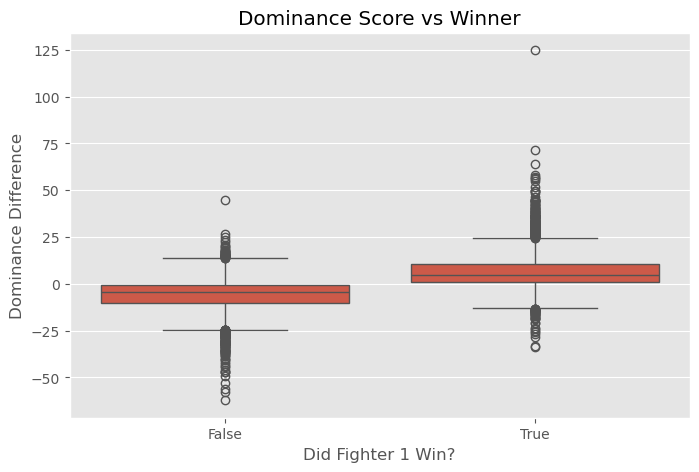

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=(fights["Winner"] == fights["Fighter_1"]),
    y=fights["dominance_diff"]
)

plt.title("Dominance Score vs Winner")
plt.xlabel("Did Fighter 1 Win?")
plt.ylabel("Dominance Difference")

plt.show()

In [20]:
fights.sort_values("dominance_diff", ascending=False)[
    ["Fighter_1","Fighter_2","dominance_diff"]
].head(10)

,Fighter_1,Fighter_2,dominance_diff
5904,Max Holloway,Calvin Kattar,124.822
4891,Max Holloway,Brian Ortega,71.571
6174,Sean O'Malley,Kris Moutinho,63.995
7275,Zhang Weili,Amanda Lemos,57.933
1791,Nate Diaz,Donald Cerrone,56.859
7535,Sean O'Malley,Marlon Vera,56.403
4129,Joanna Jedrzejczyk,Jessica Andrade,56.006
7866,Anthony Hernandez,Michel Pereira,54.886
7609,King Green,Jim Miller,51.953
2650,Sarah Kaufman,Leslie Smith,49.531


In [21]:
fights["close_fight"] = fights["dominance_diff"].abs()

fights.sort_values("close_fight")[
    ["Fighter_1","Fighter_2","Winner","dominance_diff"]
].head(10)

,Fighter_1,Fighter_2,Winner,dominance_diff
7484,Aliaskhab Khizriev,Makhmud Muradov,Draw/NC,0.000
4928,Cat Zingano,Megan Anderson,Megan Anderson,0.000
8441,Beneil Dariush,Benoit Saint Denis,Benoit Saint Denis,0.000
4469,Gian Villante,Francimar Barroso,Gian Villante,0.000
999,Josh Koscheck,Yoshiyuki Yoshida,Josh Koscheck,0.000
2793,Edson Barboza,Evan Dunham,Edson Barboza,0.000
80,Gary Goodridge,John Campetella,Gary Goodridge,0.000
8558,Gregory Rodrigues,Brunno Ferreira,Gregory Rodrigues,0.000
53,Scott Bessac,David Hood,Scott Bessac,0.000
8291,Uros Medic,Gilbert Urbina,Uros Medic,-0.001


In [22]:
df_ml = fights.copy()

df_ml = df_ml.dropna()

df_ml["target"] = (df_ml["Winner"] == df_ml["Fighter_1"]).astype(int)

features = [
"F1_Sig_Landed","F2_Sig_Landed",
"F1_TD_Landed","F2_TD_Landed",
"F1_Ctrl_Sec","F2_Ctrl_Sec",
"Total_Fight_Time_Sec"
]

X = df_ml[features]
y = df_ml["target"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
pred = model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.8308823529411765
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       625
           1       0.84      0.90      0.87      1007

    accuracy                           0.83      1632
   macro avg       0.83      0.81      0.82      1632
weighted avg       0.83      0.83      0.83      1632



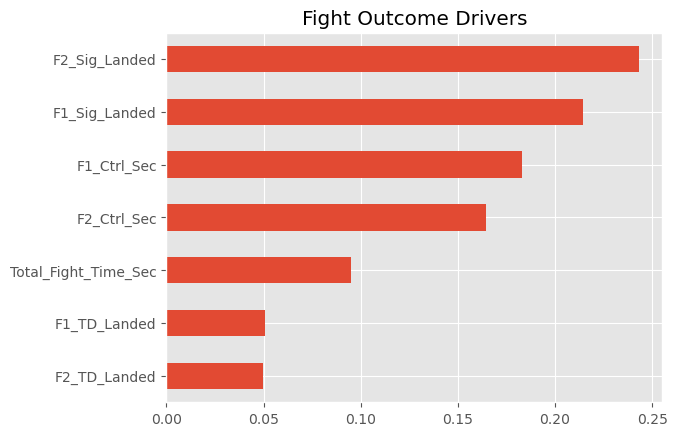

In [27]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Fight Outcome Drivers")

plt.show()